In [1]:
# ======================
# packages
# ======================

# packages
from pathlib import Path
import ssl
from urllib import request
import ppxf.sps_util as lib
import os
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from mpl_toolkits.axes_grid1 import make_axes_locatable
from astropy.wcs import WCS
import mgefit as mge


import squirrel
from squirrel.data import Datacube, Spectra
from squirrel.diagnostics import Diagnostics
from squirrel.pipeline import Pipeline

from scipy.interpolate import interp1d
from astropy.utils.masked.function_helpers import interp as astropy_interp
from astropy.cosmology import Planck18 as cosmo

import pandas as pd

from ppxf.ppxf import robust_sigma

from importlib import resources

from ppxf.ppxf import ppxf
from ppxf.ppxf_util import log_rebin, vac_to_air, air_to_vac
import ppxf.ppxf_util as util

import pickle as pkl

# speed of light
c = 299792.458 # km/s (everything ppxf outputs is in km/s)

cwd = Path.cwd()
gen_dir = os.path.join(cwd, '..', 'data/')
print(gen_dir)

obj = 'DESJ2112'
filter = 'r'
z_src = 2.359

# wavelength range
wavelength_min = 4000
wavelength_max = 6001

# binning parameters
bin_type = 'fine' # 'coarse' or 'fine'

# value for the covariances if using fine bins
if bin_type == 'fine':
    A = 0.0037196512997832057 # value obtained during the coarse binning
    snr_target = 25
elif bin_type == 'coarse':
    A = None # will be obtained from the covariance matrix
    snr_target = 70


/Users/william0billy/anaconda3/envs/kinematics/lib/python3.11/site-packages/squirrel/pipeline.py:11: UserWarning: ⚠️ VorBin is deprecated and superseded by PowerBin https://pypi.org/project/powerbin/ 
  from vorbin.voronoi_2d_binning import voronoi_2d_binning


/Users/william0billy/Research/DynamicalModeling/codes/../data/


In [2]:
# ======================
# initialize the integrated velocity dispersion measurements and the allowed templates for the ppxf fits
# ======================

# pickle path
outputs = os.path.join(cwd, '..', 'kinematics_outputs/')
pickle_path = os.path.join(outputs, f'{obj}_{filter}_combined_backup.pkl')

with open(pickle_path, 'rb') as f:
    pickled_data = pkl.load(f)

    sigma_fid = pickled_data['combined_values_final']
    sigma_fid_stat = pickled_data['combined_systematic_uncertainty_final']
    sigma_fid_syst = pickled_data['combined_statistical_uncertainty_final']
    covariance_final = pickled_data['covariance_final']
    z_defl = pickled_data['z_defl']
    z_defl_err = pickled_data['z_defl_err']

    degree_ideal = pickled_data["degree_ideal"]
    mdegree_ideal = pickled_data["mdegree_ideal"]
    refined_templates_all = pickled_data["templates_choices"]
    total_mask = pickled_data["mask"]
    noise_rescaling = pickled_data["noise_rescaling"]


In [3]:
# ======================
# Create Datacube object from the full datacube
# ======================

# spectra and cube paths
cube_path = gen_dir + f'{obj}_{filter}.fits'
noise_path = gen_dir + f'{obj}_{filter}_var.fits'

noise = np.sqrt(fits.open(noise_path)[0].data) # variance data

# open cube to extract wcs info and wavelength array
with fits.open(cube_path) as hdul:
    cube = hdul[0].data
    hdr = hdul[0].header
    wcs = WCS(hdr)
    celestial_wcs = wcs.celestial

# build wavelength array in air wavelengths (need to convert), but do not convert to rest frame
ref_lambda = hdr['CRVAL3'] # wavelength zeropoint (beginning wavelength)
if filter == 'r':
    delt = hdr['CD3_3'] # wavelength step size
else:
    delt = hdr['CDELT3'] # wavelength step size (1.0 angstroms per pixel)
npix = hdr['NAXIS3'] # number of wavelength pixels
pix = np.arange(npix) # pixel indices
crpix = hdr.get('CRPIX3', 1.0) # reference pixel (default to 1.0 if not present)
wavelengths = ref_lambda + (pix - crpix) * delt # wavelength array

wavelength_vac = ref_lambda + delt * np.arange(npix) # in angstrom, ref_lambda is start, delt is step size, npix is number of pixels
wavelength_air = vac_to_air(wavelength_vac) # convert to air wavelengths, send to rest frame\

# obtain the FWHM of the instrument using the nominal resolution and central KCRM wavelength
RM_central =  (wavelength_min + wavelength_max) * (1+z_defl) / 2 # AA
R = 1700 # KCRM resolution, see https://ui.adsabs.harvard.edu/abs/2026ApJ..1000..150C/abstract & Rosalie's email
fwhm_gal = RM_central / R # use uniform fwhm

# print point in array of CaH line (3967)
cag_line_vac = 4307.9 * (1+z_defl) # in vacuum wavelengths
cag_line_air = vac_to_air(cag_line_vac) # convert to air wavelengths
cag_index = np.argmin(np.abs(wavelength_vac - cag_line_vac))
print(cag_index)

# convert to pixels
coordinate_transform_matrix = (
    np.array([[hdr["CD1_1"], hdr["CD1_2"]],
              [hdr["CD2_1"], hdr["CD2_2"]]])
    * 3600
)

599


Set MJD-BEG to 60944.230916 from DATE-BEG.
Set MJD-END to 60944.234388 from DATE-END'. [astropy.wcs.wcs]


 Pixels used: 45
 Peak img[j, k]: 49, 50
 Mean (j, k): 49.56 49.25
 Theta (deg): 3.4
 Astro PA (deg): 86.6
 Eps: 0.041
 Major axis (pix): 4.1
Central pixel coordinates: (49.56271355649624, 49.25145634192534)


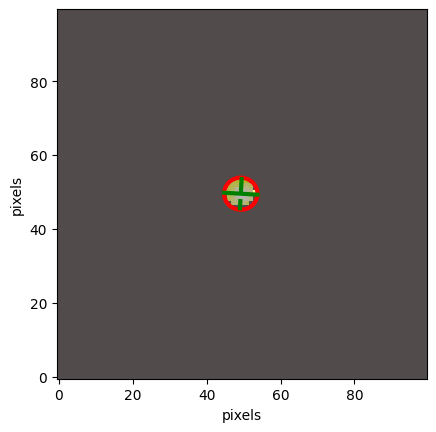

In [4]:
# ======================
# find center using multigaussian profile on datacube (CANNOT USE HST DUE TO WCS DISCREPANCIES). Just using the squirrel example version cuz no reason to add complexity
# ======================

# mask out everything but the central deflector
cube_masked = np.copy(cube)

cube_cag = cube_masked[cag_index - 4 : cag_index + 4, :, :]
cube_after_cag = cube_masked[cag_index + 15 : cag_index + 23, :, :]
central_spaxel = [49, 50]
cube_masked = cube_after_cag - cube_cag
y, x = np.ogrid[:cube_masked.shape[1], :cube_masked.shape[2]]
r = np.sqrt((x - central_spaxel[0])**2 + (y - central_spaxel[1])**2)

outer_radius = 4
cube_masked[:, (r > outer_radius)] = np.nan

f = mge.find_galaxy(
    np.nansum(cube_masked, axis=0),   # always use the QSO-subtracted cube for this
    binning=3, 
    fraction=0.1, 
    level=None,
    nblob=1, 
    plot=True, 
    quiet=False
)

center_pixel_x, center_pixel_y = f.xmed, f.ymed
print(f"Central pixel coordinates: ({center_pixel_x}, {center_pixel_y})")



In [5]:
# ======================
# Create datacube object
# ======================

datacube = Datacube(wavelengths = wavelength_air,
                    flux = cube,
                    wavelength_unit = 'AA',
                    noise = noise,
                    fwhm = fwhm_gal,
                    z_lens = z_defl,
                    z_source = z_src,
                    center_pixel_x = center_pixel_x,
                    center_pixel_y = center_pixel_y,
                    coordinate_transform_matrix = coordinate_transform_matrix
                    )


# ======================
# adjust datacube spectra
# ======================
datacube.reset()
datacube.deredshift(target_frame = 'lens')
datacube.clip(wavelength_min, wavelength_max)

print(datacube.spectra_modifications, datacube.wavelengths_frame)
print(datacube.x_coordinates.shape)
print(datacube.flux.shape, datacube.noise.shape)

['clipped'] lens frame
(100, 100)
(2893, 100, 100) (2893, 100, 100)


99 99


/var/folders/5k/qcywytnj7rdc1xdk_bq2qy8m0000gn/T/ipykernel_83943/1634939118.py:40: RuntimeWarning: invalid value encountered in divide
  snr_image = signal_image / noise_image
/Users/william0billy/anaconda3/envs/kinematics/lib/python3.11/site-packages/squirrel/pipeline.py:382: RuntimeWarning: invalid value encountered in divide
  snr_image_per_wavelength_unit = signal_image_per_wavelength_unit / noise_image


Bin-accretion Delaunay...
41  initial bins.
40  good bins.
Regularization...
Iter:    0  Diff: 3.002
Iter:    1  Diff: 0.941
Iter:    2  Diff: 0.895
Iter:    3  Diff: 0.394
Iter:    4  Diff: 0.305
Iter:    5  Diff: 0.000
Converged
Bins: 40; Single Pixels: 16/217
Capacity Fractional RMS Scatter (%): 33.70
Time Accretion: 0.01 s
Time Regularization (it=5): 0.01 s
/Users/william0billy/Research/DynamicalModeling/codes/functions


/Users/william0billy/anaconda3/envs/kinematics/lib/python3.11/site-packages/squirrel/pipeline.py:488: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


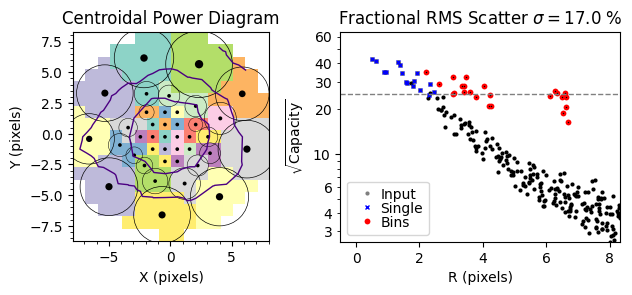

In [10]:
# ======================
# build SNR map and run power binning
# =====================

signal_image = np.zeros(datacube.flux.shape[1:]) # initialize signal image
noise_image = np.zeros(datacube.flux.shape[1:]) # initialize noise image

wavelength_mask = (datacube.wavelengths >= 
                   wavelength_min) & (datacube.wavelengths <= wavelength_max)
print(max(range(datacube.flux.shape[1])), max(range(datacube.flux.shape[2])))

# =====================
# leaving SNR as Anowar wrote it, but will prob need to change it to method used in squirrel example or some other method we talk to William about
# =====================

"""for i in range(datacube.flux.shape[1]):
    for j in range(datacube.flux.shape[2]):
        spectra = datacube.get_1d_spectra(x=j, y = i)  # x = column, y = row
        signal, cov = Diagnostics.get_specific_signal_and_noise(spectra, mask = wavelength_mask,
                                                                z_factor = 1+z_defl)
        if signal <= 0:
            signal = 0
            cov = 1e6 # make noise very large to avoid spaxel being binned; prob should use cutout in the future to avoid this issue
        signal_image[i, j] = signal
        noise_image[i, j] = np.sqrt(cov)"""

# from Anowar's example. Might need to change later on
signal_image = np.nansum(datacube.flux, axis=0) / np.sqrt(
    datacube.wavelengths[-1] - datacube.wavelengths[0]
)
noise_image = np.sqrt(np.sum(datacube.noise**2, axis=0))


# ======================
# create the binned spectra
# ======================

min_snr_per_spaxel = 1
max_radius = 2.5 # in arcseconds I think
snr_image = signal_image / noise_image

bin_mapping_outputs = Pipeline.get_power_binning_map(
    datacube=datacube,
    signal_image_per_wavelength_unit=signal_image,
    noise_image=noise_image,
    target_snr=snr_target,
    max_radius=max_radius,
    min_snr_per_spaxel=min_snr_per_spaxel,
    plot=True,
    quiet=False,
)

num_bins = len(bin_mapping_outputs)
functions_dir = cwd / 'functions'
functions_dir.mkdir(parents=True, exist_ok=True)
np.save(str(functions_dir / 'snr.npy'), snr_image)
print(functions_dir)

(array([-0.3, -0.2, -0.1,  0. ,  0.1,  0.2,  0.3,  0.4,  0.5,  0.6]),
 [Text(0, -0.30000000000000004, '−0.3'),
  Text(0, -0.20000000000000004, '−0.2'),
  Text(0, -0.10000000000000003, '−0.1'),
  Text(0, 0.0, '0.0'),
  Text(0, 0.09999999999999998, '0.1'),
  Text(0, 0.19999999999999996, '0.2'),
  Text(0, 0.30000000000000004, '0.3'),
  Text(0, 0.4, '0.4'),
  Text(0, 0.5, '0.5'),
  Text(0, 0.6, '0.6')])

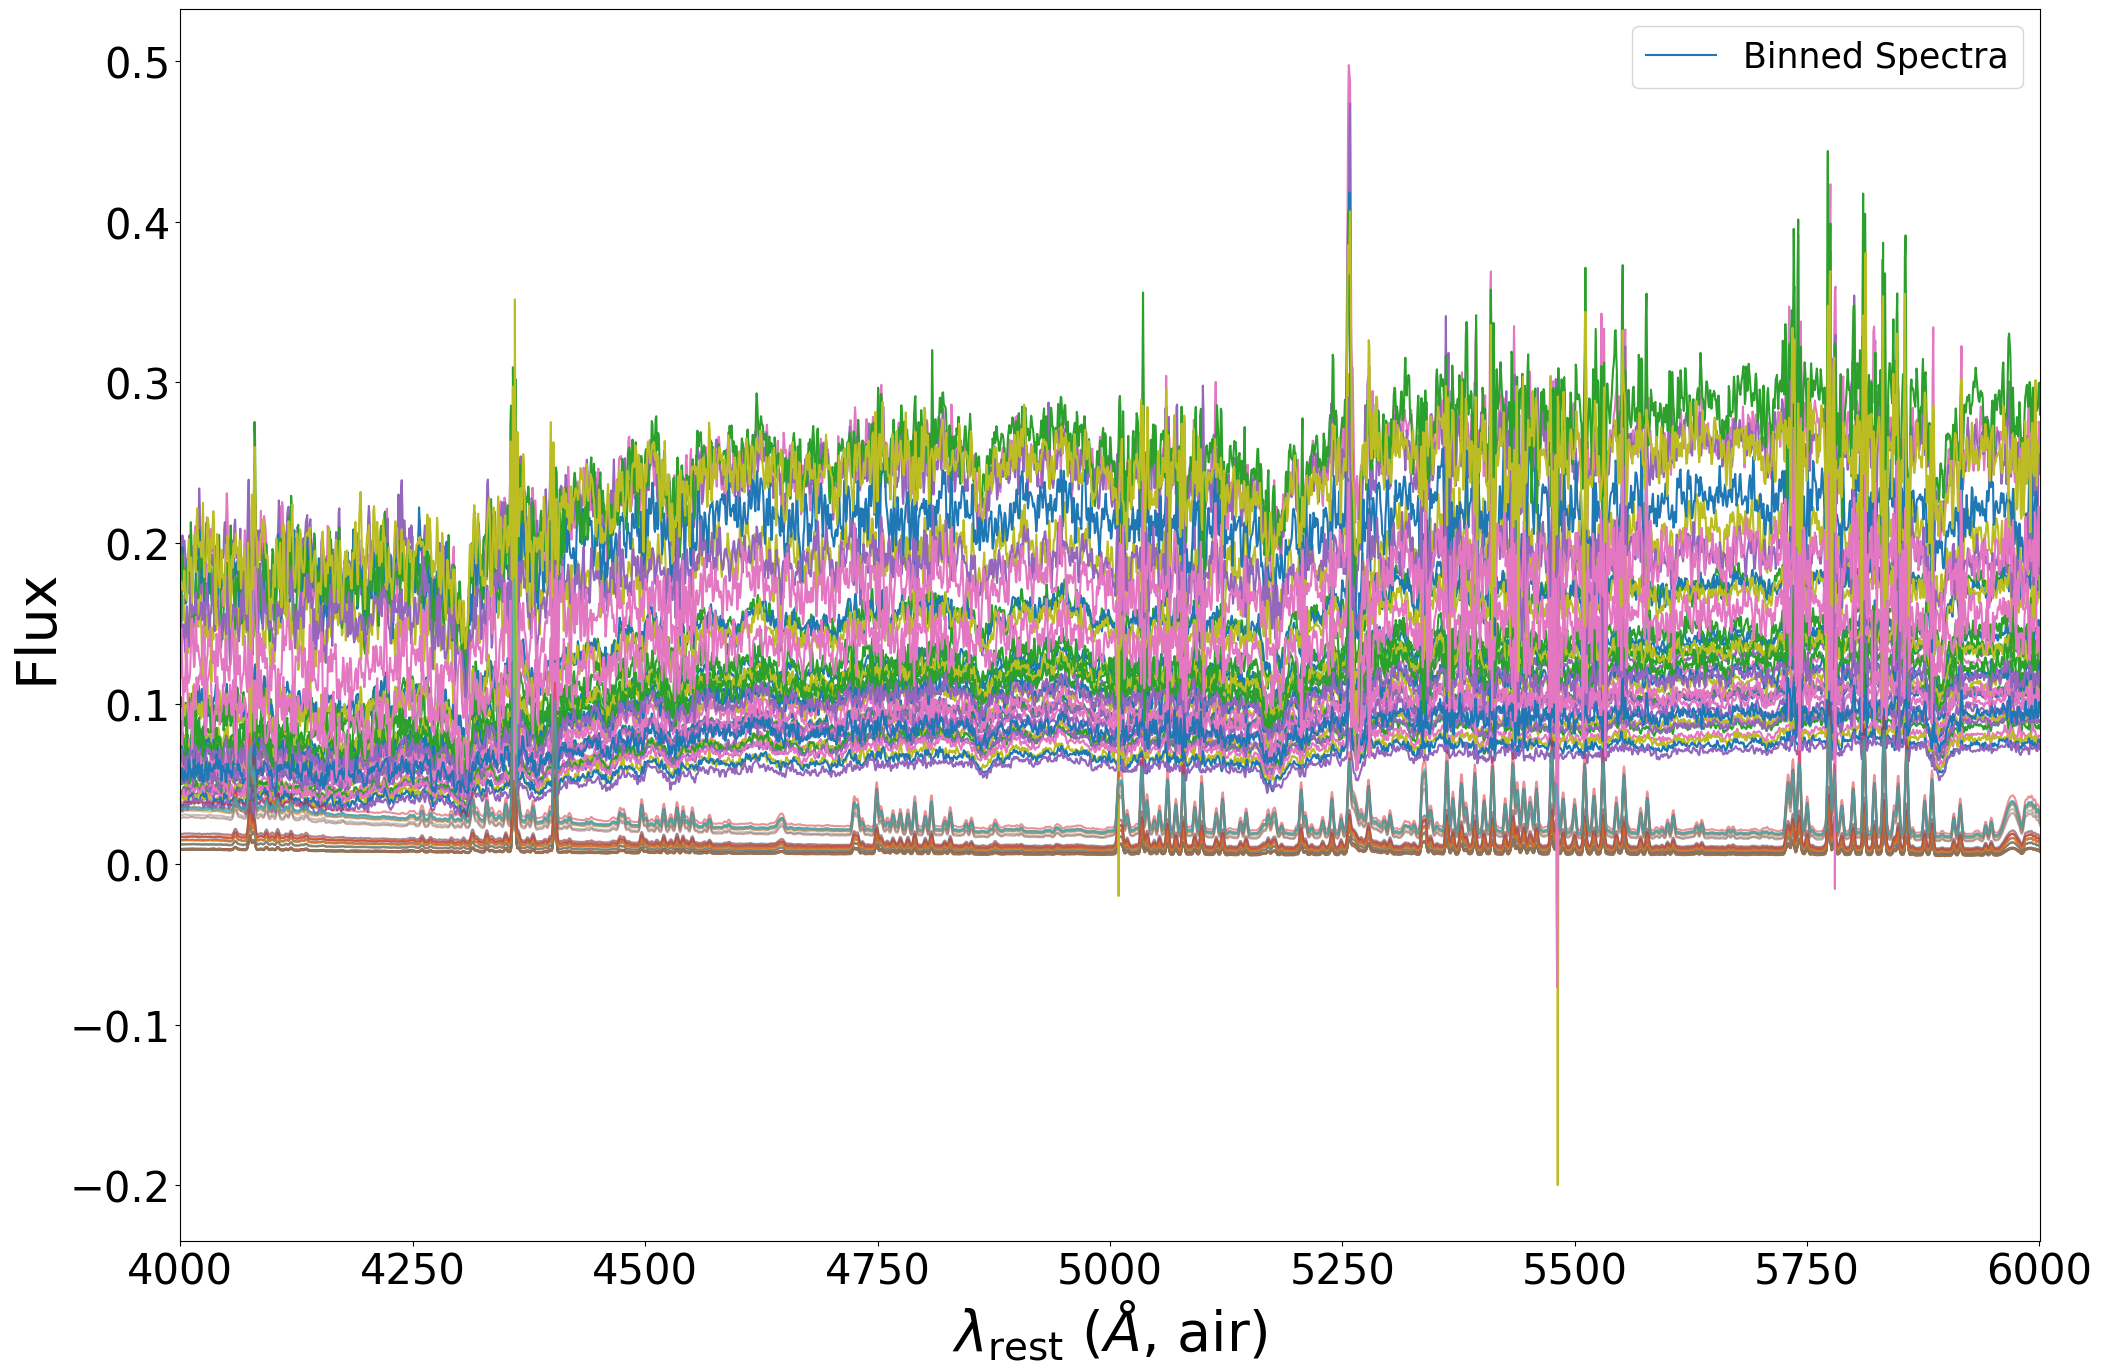

In [561]:
# ======================
# create binned spectra
# ======================

binned_spectra = Pipeline.get_power_binned_spectra(datacube, bin_mapping_outputs) # create spectra
binned_spectra.flux.shape # verify that the binned spectra have the expected shape

bin_mapping = binned_spectra.get_spaxel_map_with_bin_number() # get the spaxel map with bin numbers for plotting purposes

# rescale the noise for the binned spectra by the factor determined from the integrated fits
binned_spectra.noise *= noise_rescaling

# ======================
# obtain integrated spectrum from the binned spectra
# ======================

integrated_spectrum = datacube.get_1d_spectra(
    x=None, y=None,  # None so that the spectrum is integrated over all spaxels within the provided mask
)


# ======================
# plot all the binned spectra plus noise
# ======================

plt.figure(figsize=(24, 16))
for i in range(binned_spectra.flux.shape[1]):
    plt.plot(
        binned_spectra.wavelengths,
        binned_spectra.flux[:, i], label = f'Binned Spectra' if i == 0 else ''
    )
    plt.plot(binned_spectra.wavelengths, binned_spectra.noise[:, i], alpha=0.5)
plt.xlabel(r'$\lambda_{\rm{rest}}$ ($\AA$, air)', fontsize=40)
plt.ylabel(r"Flux", fontsize=40)
plt.legend(fontsize = 25)
plt.xticks(fontsize=30)
plt.xlim(wavelength_min, wavelength_max)
plt.yticks(fontsize=30)

In [562]:
# ======================
# log rebin the spectra
# ======================

# log rebin the binned spectra
binned_spectra = Pipeline.log_rebin(
    binned_spectra, take_covariance = False
)

100%|██████████| 40/40 [00:15<00:00,  2.53it/s]


In [563]:
# ======================
# initializations for ppxf fits
# ======================

# ======================
# create degree and mdegree combos
# ======================

degrees = np.arange(np.min(degree_ideal), np.max(degree_ideal) + 1) # just the range of polynomials chosen in the weights from integrated dispersion
mdegrees = np.arange(np.min(mdegree_ideal), np.max(mdegree_ideal) + 1)

# guesses
start = [0, 265] # initial guess for [velocity, velocity dispersion]
refined_template_names_all = ['INDO-US', 'MILES', 'XSL']


shape = (
    len(refined_templates_all),
    len(degrees),
    len(mdegrees),
    binned_spectra.flux.shape[1],
)

ppxf_fits_array = np.empty(shape, dtype=object)
dispersions = np.zeros(shape)
dispersions_err = np.zeros(shape)
velocities = np.zeros(shape)
velocities_err = np.zeros(shape)

In [564]:
# ======================
# Obtain ppxf fits for each of the binned spectra, using test polynomial orders
# ======================

for k, template in enumerate(refined_templates_all):
    for j, deg in enumerate(degrees):
        for m, mdeg in enumerate(mdegrees):
            for i in range(binned_spectra.flux.shape[1]):
                """plt.figure(figsize=(16, 12))"""

                # run ppxf on the binned spectra with the current template and polynomial orders
                ppxf_fit = Pipeline.run_ppxf(
                binned_spectra,
                template = template,
                start=start,
                spectra_indices = i,
                degree=deg,
                mdegree=mdeg,
                quiet=False,
                mask = total_mask,
                plot=False,
                )


                # map the Template object to its name
                name = refined_template_names_all[refined_templates_all.index(template)]

                ppxf_fits_array[k, j, m, i] = ppxf_fit
                dispersions[k, j, m, i] = ppxf_fit.sol[1]
                dispersions_err[k, j, m, i] = ppxf_fit.error[1]
                velocities[k, j, m, i] = ppxf_fit.sol[0]
                velocities_err[k, j, m, i] = ppxf_fit.error[0]

        
                """plt.title(f"PPXF Fit for Template {name}, Bin {i}", fontsize = 35)
                plt.text(0.05, 0.95, f"Velocity Dispersion: {ppxf_fit.sol[1]:.2f} km/s\nVelocity: {ppxf_fit.sol[0]:.2f} km/s", transform=plt.gca().transAxes, fontsize=20, verticalalignment='top')
                plt.show()"""



 Best Fit:       Vel     sigma
 comp.  0:         2       291
chi2/DOF: 0.09201; DOF: 2738; degree = 13; mdegree = 1
method = capfit; Jac calls: 3; Func calls: 14; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 12/15
Templates weights:
     0.042   0.00484    0.0228    0.0207    0.0106   0.00262   0.00981         0   0.00186    0.0006         0  0.000448         0   0.00444   0.00252
 Best Fit:       Vel     sigma
 comp.  0:         6       287
chi2/DOF: 0.09520; DOF: 2738; degree = 13; mdegree = 1
method = capfit; Jac calls: 3; Func calls: 14; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 13/15
Templates weights:
    0.0374   0.00731    0.0196    0.0156    0.0104    0.0021   0.00818         0         0   0.00401   0.00342  0.000155   0.00587    0.0023   0.00394
 Best Fit:       Vel     sigma
 comp.  0:         3       292
chi2/DOF: 0.09518; DOF: 2738; degree = 13; mdegree = 1
method = capfit; Jac calls: 3; Func calls: 14; Status: 2
linear_method = lsq_bo

In [565]:
ppxf_fits_arr = ppxf_fits_array.reshape(len(refined_templates_all) * len(degrees) * len(mdegrees), binned_spectra.flux.shape[1])
dispersions = dispersions.reshape(len(refined_templates_all) * len(degrees) * len(mdegrees), binned_spectra.flux.shape[1])
dispersions_err = dispersions_err.reshape(len(refined_templates_all) * len(degrees) * len(mdegrees), binned_spectra.flux.shape[1])
velocities = velocities.reshape(len(refined_templates_all) * len(degrees) * len(mdegrees), binned_spectra.flux.shape[1])
velocities_err = velocities_err.reshape(len(refined_templates_all) * len(degrees) * len(mdegrees), binned_spectra.flux.shape[1])

print(dispersions.shape)
print(velocities.shape)
print(velocities_err.shape)
print(ppxf_fits_arr.shape)

(6, 40)
(6, 40)
(6, 40)
(6, 40)


In [566]:
# ======================
# apply the BIC weighting to the bins, to obtain covariances
# ======================

(
    combined_dispersion_final,
    combined_systematic_uncertainty_final,
    combined_statistical_uncertainty_final,
    covariance_dispersion_final,
) = Pipeline.combine_measurements_from_templates(
    dispersions,
    dispersions_err,
    ppxf_fits_arr,
    verbose=True,
    weight_threshold=0.01,
    num_bootstrap_samples=100, 
    do_bessel_correction=True,
    num_fixed_parameters=0,
    apply_bic_weighting=True,
)




BIC weighting  applied
Weights: [9.99997817e-01 4.89519592e-18 2.18312923e-06 3.79411498e-26
 1.05403913e-34 9.11506766e-35]


In [567]:
# ======================
# do same for rotational velocities
# ======================

(
    combined_velocities_final,
    combined_velocities_systematic_uncertainty_final,
    combined_velocities_statistical_uncertainty_final,
    covariance_velocities_final,
) = Pipeline.combine_measurements_from_templates(
    velocities,
    velocities_err,
    ppxf_fits_arr,
    verbose=True,
    weight_threshold=0.01,
    num_bootstrap_samples=100, 
    do_bessel_correction=True,
    num_fixed_parameters=0,
    apply_bic_weighting=True,
)

BIC weighting  applied
Weights: [9.99999934e-01 4.41982236e-17 6.63596295e-08 1.59979470e-31
 8.63486488e-46 2.80159135e-43]


In [568]:
# ======================
# Print the combined measurements and covariances
# ======================


print("Combined Velocity Dispersions:", combined_dispersion_final)
print("Combined Systematic Uncertainties:", combined_systematic_uncertainty_final)
print("Combined Statistical Uncertainties:", combined_statistical_uncertainty_final)
print("Covariance Matrix:", covariance_dispersion_final)

print("Combined Velocities:", combined_velocities_final)
print("Combined Velocities Systematic Uncertainties:", combined_velocities_systematic_uncertainty_final)
print("Combined Velocities Statistical Uncertainties:", combined_velocities_statistical_uncertainty_final)
print("Covariance Matrix:", covariance_velocities_final)


tot_dispersion_uncertainty_final = np.sqrt(combined_systematic_uncertainty_final**2 + combined_statistical_uncertainty_final**2)
tot_velocities_uncertainty_final = np.sqrt(combined_velocities_systematic_uncertainty_final**2 + combined_velocities_statistical_uncertainty_final**2)


Combined Velocity Dispersions: [290.6756009  287.47410521 291.88802267 287.59420435 281.25067777
 284.54497065 285.94585635 286.2699298  280.40046965 272.61336598
 264.17002046 277.3775876  284.13947728 277.22762196 280.13677271
 293.89693074 260.98850914 263.64880258 268.2140616  254.2335747
 280.54825451 269.85806124 261.83916075 253.31119722 255.24664258
 268.83627077 253.03817609 265.08252252 232.29323415 262.72302792
 260.30860836 246.43176065 228.45116331 270.84696308 228.30756026
 259.81008625 228.66690941 232.52674603 214.1967394  271.00394107]
Combined Systematic Uncertainties: [0.03695108 0.04623323 1.06866686 0.9030723  0.27591197 0.27068377
 0.22125406 0.29524236 0.25383028 0.43542501 0.80266156 1.05954329
 1.28552223 0.90364453 0.52250088 0.81215188 1.38675581 1.24878085
 0.06220252 1.42924065 1.39548122 2.25002565 2.07344847 1.86908946
 0.06850607 1.78870612 2.08358897 0.60071101 0.15446967 2.8452601
 1.37769491 1.2006854  0.85587531 3.61297487 0.96604113 6.01909621
 3.01

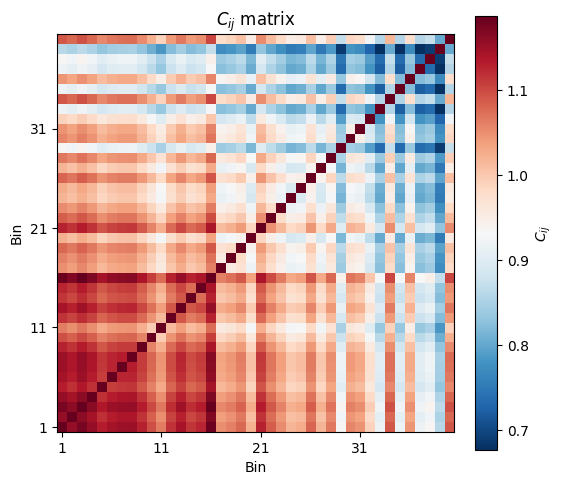

In [ ]:
cov = np.array(covariance_dispersion_final)
n = cov.shape[0]

fig, ax = plt.subplots(figsize=(6, 5))
# center colormap on zero
vmax = np.nanmax(cov)

# ticks
ticks = np.arange(n)
ax.set_xticks(ticks)
if bin_type == 'coarse':
    ticks = np.arange(0, n, 1)
elif bin_type == 'fine':
    ticks = np.arange(0, n, 10)
ax.set_xticks(ticks)
ax.set_yticks(ticks)
ax.set_xticklabels((ticks + 1).astype(str))
ax.set_yticklabels((ticks + 1).astype(str))
ax.set_xlabel("Bin")
ax.set_ylabel("Bin")
ax.set_title(r"$C_{ij}$ matrix")

cov_for_cmap = np.zeros_like(cov) # for showing covariance matrix of coarse bins
cov_for_A = [] # for obtaining A
cov_for_color=[]

for i in range(n):
    for j in range(n):
        if i != j:
            if bin_type == 'coarse':
                cov_for_cmap[i,j] = np.abs(cov[i,j])
                ax.text(j, i, f"{cov_for_cmap[i,j]:.2f}", ha="center", va="center", color="white" if abs(cov_for_cmap[i,j]) > 0.6*vmax else "black", fontsize=9)
                cov_for_A.append(np.sqrt(np.abs(cov[i,j]) / (combined_dispersion_final[i] * combined_dispersion_final[j])))
                cov[i,j] = cov_for_A[i+j-1]
            else:
                cov[i, j] = A**2 * (combined_dispersion_final[i] * combined_dispersion_final[j])
                cov_for_color.append(cov[i,j])
        if i == j and bin_type == 'coarse':
            cov_for_cmap[i,j] = cov[i,j]
            ax.text(j, i, f"{cov[i,j]:.2f}", ha="center", va="center", color="white" if abs(cov[i,j]) > 0.6*vmax else "black", fontsize=9)





if bin_type == 'fine':
    # display covariance matrix
    cov_display = cov.copy()
    im = ax.imshow(cov_display, origin="lower", cmap="RdBu_r", vmin=np.nanmin(cov_for_color), vmax=np.nanmax(cov_for_color))

if bin_type == 'coarse':

    # display the covariance matrix
    cov_display = cov_for_cmap.copy()
    im = ax.imshow(cov_display, origin="lower", cmap="RdBu_r", vmin = -vmax, vmax = vmax)

    # obtain the A value
    print("avg A", np.mean(cov_for_A))


    
cbar = fig.colorbar(im, ax=ax, fraction=0.2, pad=0.04)
cbar.set_label(r"$C_{ij}$")
plt.tight_layout()
plt.show()



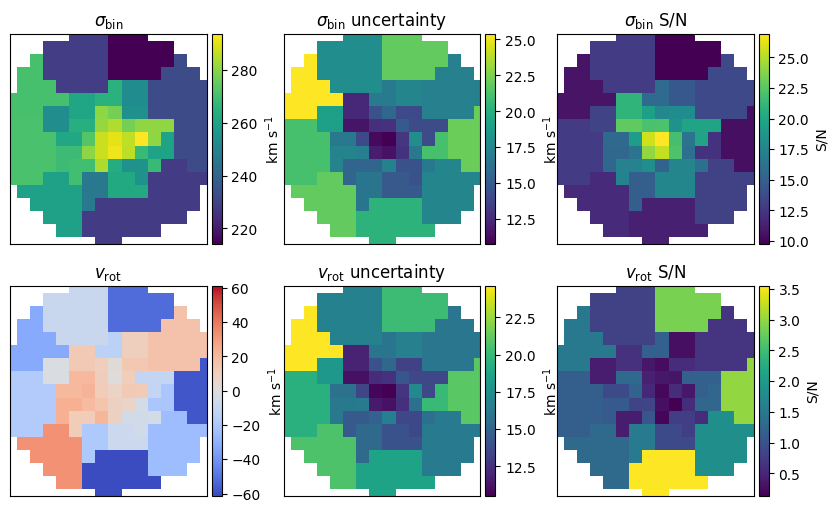

In [574]:
# ======================
# Build velocity + velocity dispersion map
# ======================

fig, axes = plt.subplots(2, 3, figsize=(10, 6))

def plot_map(
    ax,
    data,
    title,
    cmap="viridis",
    vmax=None,
    vmin=None,
    symmetrize_cmap=False,
    unit="",
    pad = 0
):
    """
    Plot a 2D map with colorbar

    :param ax: matplotlib axis
    :type ax: matplotlib axis
    :param data: 2D data array
    :type data: np.ndarray
    :param title: Title of the plot
    :type title: str
    :param symmetrize_cmap: whether to symmetrize the colormap
    :type symmetrize_cmap: bool
    :return: None
    :rtype: None
    """
    # xlims = 20, 30
    # ylims = 20, 30


    if symmetrize_cmap:
        vmax = np.nanmax(np.abs(data))
        vmin = -np.nanmax(np.abs(data))
        # print(vmax, vmin)

    im = ax.imshow(
        data,
        cmap=cmap,
        origin="lower",
        vmax=vmax,
        vmin=vmin,
    )
    
   # Zoom in on the non-NaN region
    finite = np.isfinite(data)

    if np.any(finite):
        y, x = np.where(finite)

        xmin = max(x.min() - pad, 0)
        xmax = min(x.max() + pad, data.shape[1] - 1)
        ymin = max(y.min() - pad, 0)
        ymax = min(y.max() + pad, data.shape[0] - 1)

        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)

    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])

    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    fig.colorbar(im, cax=cax, label=unit)

plot_map(
    axes[0, 0],
    Pipeline.create_kinematic_map_from_bins(
        bin_mapping, combined_dispersion_final, nan_outside_bins=True,
    ),
    r"$\sigma_{\rm{bin}}$",
    unit=r"$\rm km\ s^{-1}$",
    # vmax=350,
    # vmin=170,
)
plot_map(
    axes[0, 1],
    Pipeline.create_kinematic_map_from_bins(
        bin_mapping, tot_dispersion_uncertainty_final, nan_outside_bins=True,
    ),
    r"$\sigma_{\rm{bin}}$ uncertainty",
    unit=r"$\rm km\ s^{-1}$",
)
plot_map(
    axes[0, 2],
    Pipeline.create_kinematic_map_from_bins(
        bin_mapping, combined_dispersion_final/tot_dispersion_uncertainty_final, nan_outside_bins=True,
    ),
    r"$\sigma_{\rm{bin}}$ S/N",
    unit="S/N",
)


plot_map(
    axes[1, 0],
    Pipeline.create_kinematic_map_from_bins(
        bin_mapping, combined_velocities_final - np.mean(combined_velocities_final), nan_outside_bins=True,
    ),
    r"$v_{\rm{rot}}$",
    cmap="coolwarm",
    symmetrize_cmap=True,
    unit=r"$\rm km\ s^{-1}$",
)
plot_map(
    axes[1, 1],
    Pipeline.create_kinematic_map_from_bins(
        bin_mapping, tot_velocities_uncertainty_final, nan_outside_bins=True,
    ),
    r"$v_{\rm{rot}}$ uncertainty",
    unit=r"$\rm km\ s^{-1}$",
)
plot_map(
    axes[1, 2],
    Pipeline.create_kinematic_map_from_bins(
        bin_mapping, 
        np.abs(combined_velocities_final) / tot_velocities_uncertainty_final, nan_outside_bins=True,
    ),
    r"$v_{\rm{rot}}$ S/N",
    unit="S/N",
)
plt.show()

0.06252824746618506 0.9957654610797345


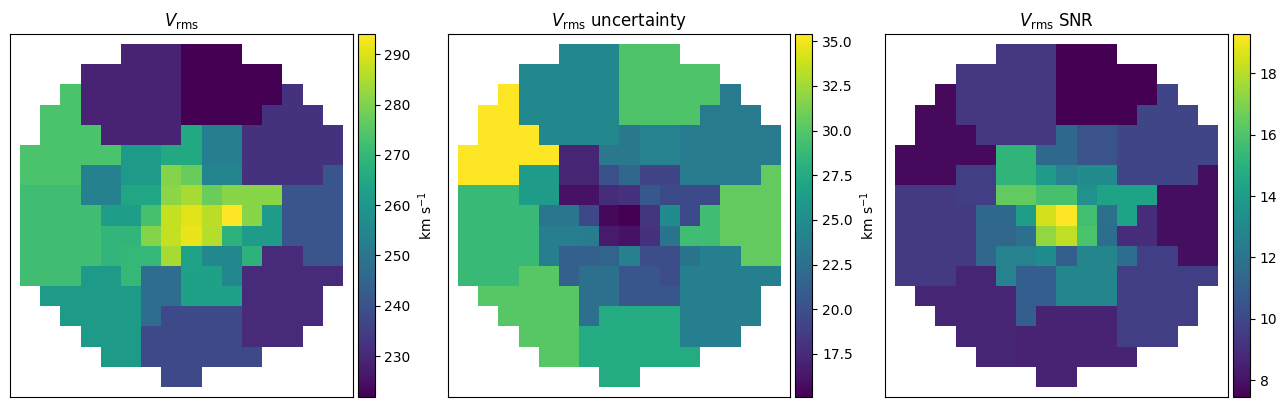

In [587]:
# ======================
# extract RMS velocities
# ===================== 

combined_rms_velocities_final = np.sqrt(combined_velocities_final**2 + combined_dispersion_final**2)
combined_rms_velocities_uncertainty_final = np.sqrt(tot_velocities_uncertainty_final**2 + tot_dispersion_uncertainty_final**2)

v_rot_fraction = np.abs(combined_velocities_final) / combined_rms_velocities_final
dispersion_fraction = combined_dispersion_final / combined_rms_velocities_final
print(np.mean(v_rot_fraction), np.mean(dispersion_fraction))




# plot the rms velocity maps

fig, axes = plt.subplots(1, 3, figsize=(16, 6))

plot_map(
    axes[0],
    Pipeline.create_kinematic_map_from_bins(
        bin_mapping, combined_rms_velocities_final, nan_outside_bins=True,
    ),
    r"$V_{\rm{rms}}$",
    unit=r"$\rm km\ s^{-1}$",
    # vmax=350,
    # vmin=170,
    pad = 1
)
plot_map(
    axes[1],
    Pipeline.create_kinematic_map_from_bins(
        bin_mapping, combined_rms_velocities_uncertainty_final, nan_outside_bins=True,
    ),
    r"$V_{\rm{rms}}$ uncertainty",
    unit=r"$\rm km\ s^{-1}$",
    pad = 1
)

plot_map(
    axes[2],
    Pipeline.create_kinematic_map_from_bins(
        bin_mapping, combined_rms_velocities_final / combined_rms_velocities_uncertainty_final, nan_outside_bins=True,
    ),
    r"$V_{\rm{rms}}$ SNR",
    unit=r"",
    pad = 1
)



[ 0.89319859  1.09136103  2.3473492   2.42967352  1.65820399  1.53504895
  3.3745517   2.58367077  3.2525418   2.80270408  3.88552679  2.86948187
  4.10930336  3.19151421  3.54505215  4.33863131  5.40305062  4.06117088
  6.05552509  4.62100048  6.15011744  6.0441292   5.44142006  7.52592767
  5.90147005  6.36974149  6.69742541  5.46020883 11.09843144  7.16307747
  7.44653517  7.46353071 11.67578052 11.84617703 11.75494725 11.51399793
 10.83799545 11.71708949 11.5493862  11.25080285]


/var/folders/5k/qcywytnj7rdc1xdk_bq2qy8m0000gn/T/ipykernel_50305/4150214409.py:19: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  fid_disp_uncertainty = float(np.sqrt(sigma_fid_stat**2 + sigma_fid_syst**2))
/var/folders/5k/qcywytnj7rdc1xdk_bq2qy8m0000gn/T/ipykernel_50305/4150214409.py:33: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  label=rf"Integrated $\sigma = {float(sigma_fid):.2f}\pm{fid_disp_uncertainty:.2f}$ km/s"


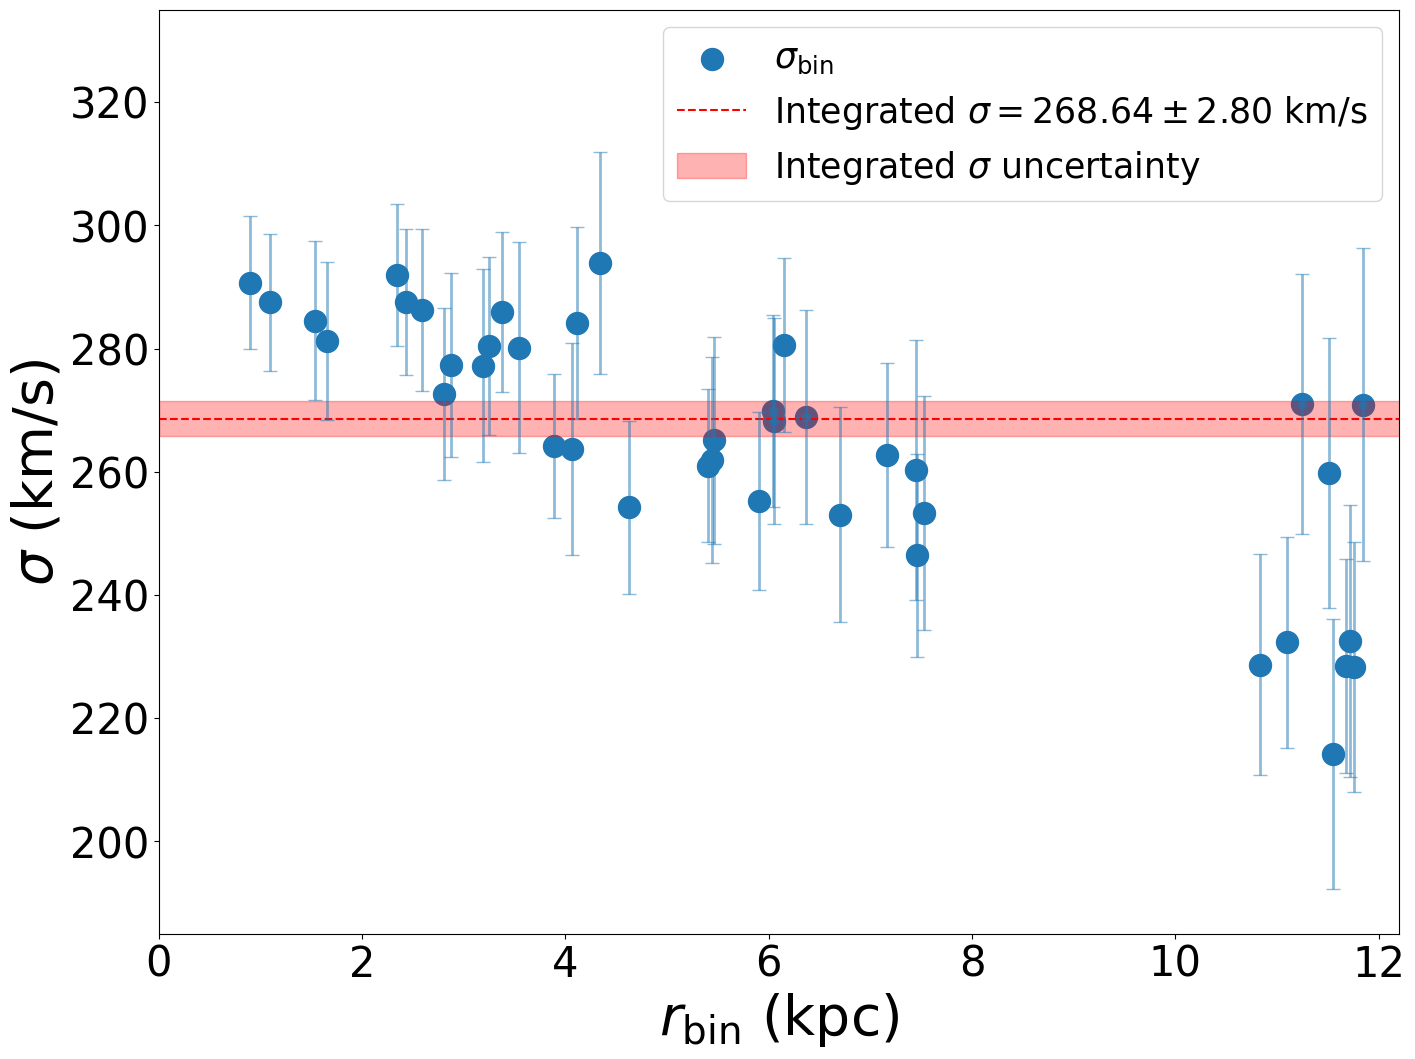

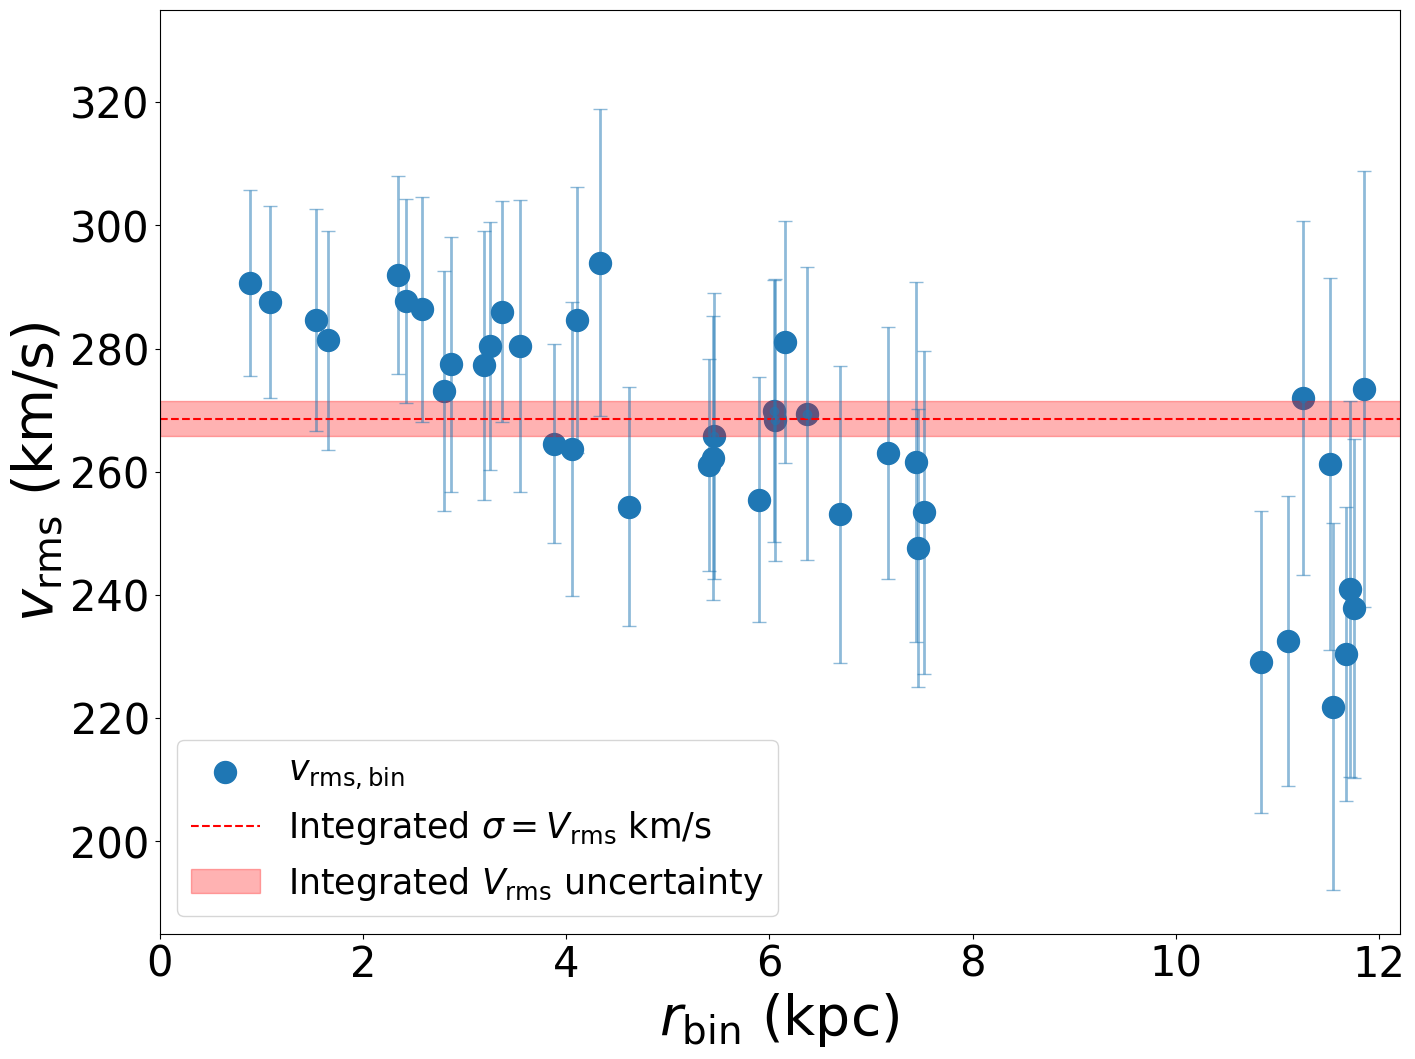

In [649]:
# ======================
# velocity dispersion and velocity as function of radius
# ======================

dispersion_map = Pipeline.create_kinematic_map_from_bins(
    bin_mapping, combined_dispersion_final)

velocity_map = Pipeline.create_kinematic_map_from_bins(
    bin_mapping, combined_velocities_final)

# create radius map
bin_radii = np.sqrt(binned_spectra.bin_center_x**2 + binned_spectra.bin_center_y**2)
# convert bin radii to kpc using the angular diameter distance to the lens
angular_diameter_distance = cosmo.angular_diameter_distance(z_defl).to('kpc').value
bin_radii_kpc = bin_radii * angular_diameter_distance / 206265 # convert from arcseconds to radians
print(bin_radii_kpc)

# uncertqainty of fiducial velocity dispersion
fid_disp_uncertainty = float(np.sqrt(sigma_fid_stat**2 + sigma_fid_syst**2))


# plot velocity dispersion and velocity as function of radius
plt.figure(figsize=(16, 12))
plt.xticks(fontsize=30)
plt.yticks(fontsize=30
               )
plt.scatter(bin_radii_kpc, combined_dispersion_final, s = 250, label = r"$\sigma_{\rm{bin}}$")

plt.axhline(
    sigma_fid,
    color='r',
    linestyle='--',
    label=rf"Integrated $\sigma = {float(sigma_fid):.2f}\pm{fid_disp_uncertainty:.2f}$ km/s"
)
plt.fill_between([0, 15], sigma_fid - fid_disp_uncertainty, sigma_fid + fid_disp_uncertainty, alpha=0.3, color='r', label='Integrated $\sigma$ uncertainty')
plt.errorbar(bin_radii_kpc, combined_dispersion_final, yerr=tot_dispersion_uncertainty_final, fmt = 'o', capsize = 5, elinewidth = 2, alpha = 0.5)
plt.legend(fontsize = 25)
plt.xlabel(r"$r_{\rm{bin}}$ (kpc)", fontsize =40)
plt.ylabel(r"$\sigma$ (km/s)", fontsize =40)
plt.xlim(0,12.2)
plt.ylim(185, 335)
plt.show()



# plot velocity as function of radius
plt.figure(figsize=(16, 12))
plt.xticks(fontsize=30)
plt.yticks(fontsize=30)
plt.scatter(bin_radii_kpc, combined_rms_velocities_final, s = 250, label = r"$v_{\rm{rms, bin}}$")
plt.errorbar(bin_radii_kpc, combined_rms_velocities_final, yerr=combined_rms_velocities_uncertainty_final, fmt = 'o', capsize = 5, elinewidth = 2, alpha = 0.5)
plt.axhline(
    sigma_fid,
    color='r',
    linestyle='--',
    label=r"Integrated $\sigma = V_{\rm{rms}}$ km/s"
)
plt.fill_between([0, 15], sigma_fid - fid_disp_uncertainty, sigma_fid + fid_disp_uncertainty, alpha=0.3, color='r', label=r'Integrated $V_{\rm{rms}}$ uncertainty')
plt.legend(fontsize = 25)
plt.xlabel(r"$r_{\rm{bin}}$ (kpc)", fontsize =40)
plt.ylabel(r"$v_{\rm{rms}}$ (km/s)", fontsize =40)
plt.xlim(0,12.2)
plt.ylim(185, 335)
plt.show()

In [ ]:
# ======================
# save all the spatially resolved kinematic outputs to a pickle file
# ======================

pickle_path = os.path.join(outputs, f'{obj}_{filter}_spatially_resolved_kinematics.pkl')

with open(pickle_path, 'wb') as f:
    save_data = {
        'bin_mapping': bin_mapping, #Bin ID for each spaxel, ranging from 0 to n_bin-1, or -1 for excluded pixels.
        'x_coordinates': datacube.x_coordinates, # float array with shape (n_y, n_x). x-coordinate of each spaxel (in arcseconds).
        'y_coordinates': datacube.y_coordinates, #float array with shape (n_y, n_x). y-coordinate of each spaxel (in arcseconds).
        'bin_center_x': binned_spectra.bin_center_x, # x-coordinate of the center of each bin (in arcseconds).
        'bin_center_y': binned_spectra.bin_center_y, # y-coordinate of the center of each bin (in arcseconds).
        'center_x': center_pixel_x, # x-coordinate of the center of the datacube (in pixels).
        'center_y': center_pixel_y, # y-coordinate of the center of the datacube (in pixels).
        
        
        'combined_dispersion_final': combined_dispersion_final,
        'combined_systematic_uncertainty_final': combined_systematic_uncertainty_final,
        'combined_statistical_uncertainty_final': combined_statistical_uncertainty_final,
        'covariance_dispersion_final': cov, # dispersion covariance matrix
        'covariance_velocities_final': covariance_velocities_final, # velocities covariance matrix
        'combined_velocities_final': combined_velocities_final,
        'combined_velocities_systematic_uncertainty_final': combined_velocities_systematic_uncertainty_final,
        'combined_velocities_statistical_uncertainty_final': combined_velocities_statistical_uncertainty_final,
        'combined_rms_velocities_final': combined_rms_velocities_final,
        'combined_rms_velocities_uncertainty_final': combined_rms_velocities_uncertainty_final,}

    pkl.dump(save_data, f)

NameError: name 'os' is not defined